In [38]:
import sys
import pypsa
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
idx = pd.IndexSlice

sys.path.append(str(Path.cwd().parent / 'scripts'))
from _tyndp_helpers import _extract_scenario_values, _extract_scenario_values_rowwise

In [15]:
def to_ac_bus(x):
    return ' '.join(x.split(' ')[:2])

In [4]:
valpath = Path.cwd().parent / 'data' / 'TYNDP_2024-Scenario-Report-Data-Figures_240522.xlsx'

In [31]:
def get_ylimmax(args):
    ylimmax = 0

    for arg in args:
        if isinstance(arg, list):
            ylimmax = max(ylimmax, max(arg))
        elif isinstance(arg, dict):
            ylimmax = max(ylimmax, max(
                [arg['National Trends'][2030], arg['National Trends'][2040], arg['Distributed Energy'][2040], arg['Global Ambition'][2040]]
                )
            )
    return ylimmax

In [6]:
# ---------------------------------------------------------------------------
# Power capacity mix, EU27 (GW)
# Sheet: '25-'  |  Row label: Gas, Solar, Wind Onshore, Wind Offshore, Nuclear, Battery
# ---------------------------------------------------------------------------

def gas_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Methane')

def solar_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Solar')

def wind_onshore_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Wind Onshore')

def wind_offshore_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Wind Offshore')

def nuclear_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Nuclear')

def battery_power_capacity_mix(path):
    return _extract_scenario_values_rowwise(path, '25-', 'Battery')


In [25]:
n = pypsa.Network(
    Path.cwd().parent / 'results' / 'networks' / 'base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc'
)

years = [2030, 2035]
ns = {
    year: pypsa.Network(
        Path.cwd().parent / 'results' / 'networks' / f'base_s_50__168H-T-H-B-I-A-dist1_{year}_NT_+0.00.nc'
    ) for year in years
}

INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2030_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores
INFO:pypsa.io:Imported network base_s_50__168H-T-H-B-I-A-dist1_2035_NT_+0.00.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


In [14]:
eu27_countries = [
    "AT", "BE", "BG", "HR", "CY", "CZ", "DK", "EE", "FI", "FR", "DE", "GR", "HU",
    "IE", "IT", "LV", "LT", "LU", "MT", "NL", "PL", "PT", "RO", "SK", "SI", "ES", "SE",
]
eu27_buses = n.buses.index[
    (n.buses.country.isin(eu27_countries)) &
    (n.buses.carrier == 'AC')
]
all_eu27_buses = n.buses.index[
    (n.buses.country.isin(eu27_countries))
]

In [27]:
cs = n.statistics.optimal_capacity().index.get_level_values(1).unique()

capacities = {
    'offwind': ['Offshore Wind (AC)', 'Offshore Wind (DC)', 'Offshore Wind (Floating)'],
    'onwind': ['Onshore Wind'],
    'solar': ['Solar', 'solar-hsat'],
    'hydro': ['Run of River', 'Reservoir & Dam'],
    'gas': ['Combined-Cycle Gas', 'Open-Cycle Gas'],
    'coal': ['coal', 'lignite'],
    'nuclear': ['nuclear'],
    'battery': ['Battery Storage'],
    'PHS': ['Pumped Hydro Storage'],
    'electrolyser': ['H2 Electrolysis'],
}

In [20]:
ss = n.statistics.optimal_capacity(groupby=['carrier', 'bus'])

ss = ss.loc[
    idx[
        :, :, ss.index.get_level_values(2).isin(all_eu27_buses.tolist() + ['EU coal', 'EU lignite', 'EU uranium', 'EU gas'])
        ]
    ]
ss = ss.groupby(level=[0, 1]).sum()

In [33]:
gas_capacity = gas_power_capacity_mix(valpath)
solar_capacity = solar_power_capacity_mix(valpath)
onwind_capacity = wind_onshore_power_capacity_mix(valpath)
offwind_capacity = wind_offshore_power_capacity_mix(valpath)
nuclear_capacity = nuclear_power_capacity_mix(valpath)
battery_capacity = battery_power_capacity_mix(valpath)

In [29]:
data = []

for year in years:

    year_caps = []
    
    caps = ns[year].statistics.optimal_capacity(groupby=['carrier', 'bus'])
    # caps = caps.loc[idx[:, :, caps.index.get_level_values(2).isin(all_eu27_buses.tolist() + ['EU coal', 'EU lignite', 'EU uranium', 'EU gas'])]]
    caps = caps.groupby(level=[0, 1]).sum()

    for name, carriers in capacities.items():
        
        if name in ['coal', 'gas']:
            carriers = caps.loc[idx['Link']].index.intersection(carriers)
            year_caps.append(caps.loc[idx['Link', carriers]].sum() * 1e-3)
        elif name in ['nuclear']:
            year_caps.append(caps.loc[idx['Generator', carriers]].sum() * 1e-3)
        else:
            year_caps.append(caps.loc[idx[:, carriers]].sum() * 1e-3)

    year_caps = pd.DataFrame({year: year_caps}, index=capacities.keys())
    data.append(year_caps)

data = pd.concat(data, axis=1)
data

,2030,2035
offwind,155.166388,263.458970
onwind,384.878156,463.655922
solar,669.433939,897.651511
hydro,151.112994,151.112994
gas,24.397738,8.667884
coal,0.000000,0.000000
nuclear,101.795197,106.371017
battery,142.066369,262.418542
PHS,55.810136,55.810136
electrolyser,0.077038,19.600198


In [35]:
ylimmax = get_ylimmax([
    data.values.flatten(),
    gas_capacity,
    solar_capacity,
    onwind_capacity,
    offwind_capacity,
    nuclear_capacity,
    battery_capacity
    ]) * 1.1

In [36]:
tyndp_colors = {
    'National Trends': '#fe4a49',
    'Distributed Energy': '#2ab7ca',
    'Global Ambition': '#fed766',
}
def darken_color(color, factor=0.7):
    rgb = mcolors.to_rgb(color)
    return tuple(c * factor for c in rgb)

def data_to_plot(
    ax,
    years,
    model_data,
    tyndp_data=None,
    title=None,
    ylabel=None,
    ylimmax=None,
    ):

    color = np.random.rand(3,)
    ax.plot(years, model_data, marker='o', color=color)

    gradient = (model_data[-1] - model_data[len(years)//2]) / (years[-1] - years[len(years)//2])

    extrapolation_years = [years[-1], 2040]
    extrapolation = [model_data[-1], model_data[-1] + gradient * (2040 - years[-1])]

    ax.plot(extrapolation_years, extrapolation, linestyle='--', color=color)

    if title is not None:
        ax.set_title(title)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

    used_data = [0]
    if tyndp_data is not None:
        ax.scatter(
            [2030, 2040],
            [tyndp_data['National Trends'][2030], tyndp_data['National Trends'][2040]],
            color=tyndp_colors['National Trends'],
            edgecolors=darken_color(tyndp_colors['National Trends']),
            s=100,
            alpha=0.5,
            )
        ax.scatter(
            [2040],
            [tyndp_data['Distributed Energy'][2040]],
            color=tyndp_colors['Distributed Energy'],
            edgecolors=darken_color(tyndp_colors['Distributed Energy']),
            s=100,
            alpha=0.5,
            )
        ax.scatter(
            [2040],
            [tyndp_data['Global Ambition'][2040]],
            color=tyndp_colors['Global Ambition'],
            edgecolors=darken_color(tyndp_colors['Global Ambition']),
            s=100,
            alpha=0.5,
        )
        used_data = [
            tyndp_data['National Trends'][2030],
            tyndp_data['National Trends'][2040],
            tyndp_data['Distributed Energy'][2040],
            tyndp_data['Global Ambition'][2040],
        ]

    if ylimmax is None:
        ax.set_ylim(0, max(max(model_data), max(used_data)) * 1.1)
    else:
        ax.set_ylim(0, ylimmax)

    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Year')

    ax.set_xlim(2024, 2041)
    ax.set_xticks([2025, 2030, 2035, 2040])

/tmp/ipykernel_243715/3327672303.py:23: RuntimeWarning: invalid value encountered in divide
  gradient = (model_data[-1] - model_data[len(years)//2]) / (years[-1] - years[len(years)//2])


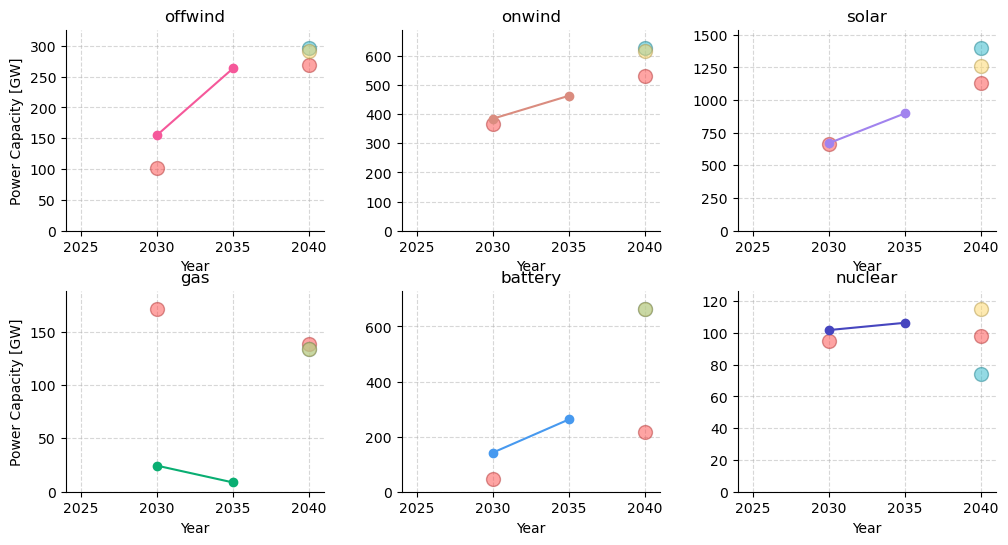

In [45]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6))

showers = [
    'offwind', 'onwind', 'solar', 'gas', 'battery', 'nuclear'
]

for i, carrier in enumerate(showers):
    ax = axs.flatten()[i]
    row = data.loc[carrier]

    if carrier+'_capacity' in globals():
        kwargs = {'tyndp_data': globals()[carrier+'_capacity']}
    else:
        kwargs = {}
    
    # data_to_plot(ax, row.index, list(row), title=name, ylimmax=ylimmax, **kwargs)
    data_to_plot(ax, row.index, list(row), title=carrier, ylimmax=None, **kwargs)

for ax in axs[:,0]:
    ax.set_ylabel('Power Capacity [GW]')

fig.subplots_adjust(hspace=0.3, wspace=0.3)
plt.show()

In [48]:
n.links.loc[n.links.carrier == 'heat>500 industry hydrogen'].head()

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,underwater_fraction,tags,location,underground,geometry,project_status,under_construction,voltage,dc,length_original
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 heat>500 industry hydrogen,AL0 0 H2,AL0 0 heat>500 industry,,heat>500 industry hydrogen,1.0,True,0,15.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
AT0 0 heat>500 industry hydrogen,AT0 0 H2,AT0 0 heat>500 industry,,heat>500 industry hydrogen,1.0,True,0,15.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
BA0 0 heat>500 industry hydrogen,BA0 0 H2,BA0 0 heat>500 industry,,heat>500 industry hydrogen,1.0,True,0,15.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
BE0 0 heat>500 industry hydrogen,BE0 0 H2,BE0 0 heat>500 industry,,heat>500 industry hydrogen,1.0,True,0,15.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
BG0 0 heat>500 industry hydrogen,BG0 0 H2,BG0 0 heat>500 industry,,heat>500 industry hydrogen,1.0,True,0,15.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0


In [55]:
# n.statistics.energy_balance().loc[idx[:, :, 'H2']]
n.statistics.energy_balance().index.get_level_values(2).unique()

Index(['AC', 'Hydrogen Storage', 'NH3', 'low voltage', 'rural heat',
       'agriculture machinery oil', 'coal for industry',
       'heat100-200 industry', 'heat200-500 industry', 'heat>500 industry',
       'kerosene for aviation', 'EV battery', 'land transport oil',
       'urban central heat', 'urban decentral heat', 'naphtha for industry',
       'shipping methanol', 'shipping oil', 'solid biomass for industry',
       'biogas', 'co2', 'coal', 'gas', 'oil primary', 'solid biomass',
       'unsustainable bioliquids', 'Battery Storage', 'co2 sequestered',
       'home battery', 'non-sequestered HVC', 'co2 stored', 'oil', 'methanol'],
      dtype='object', name='bus_carrier')

In [58]:
n.links.loc[
    (n.links.bus0.str.contains('H2')) |
    (n.links.bus1.str.contains('H2')) |
    (n.links.bus2.str.contains('H2')) |
    (n.links.bus3.str.contains('H2'))
]

,bus0,bus1,type,carrier,efficiency,active,build_year,lifetime,p_nom,p_nom_mod,...,underwater_fraction,tags,location,underground,geometry,project_status,under_construction,voltage,dc,length_original
Link,,,,,,,,,,,,,,,,,,,,,
AL0 0 H2 Electrolysis,AL0 0,AL0 0 H2,,H2 Electrolysis,0.5874,True,0,25.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
AT0 0 H2 Electrolysis,AT0 0,AT0 0 H2,,H2 Electrolysis,0.5874,True,0,25.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
BA0 0 H2 Electrolysis,BA0 0,BA0 0 H2,,H2 Electrolysis,0.5874,True,0,25.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
BE0 0 H2 Electrolysis,BE0 0,BE0 0 H2,,H2 Electrolysis,0.5874,True,0,25.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
BG0 0 H2 Electrolysis,BG0 0,BG0 0 H2,,H2 Electrolysis,0.5874,True,0,25.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
RS0 0 Fischer-Tropsch,RS0 0 H2,EU oil,,Fischer-Tropsch,0.7990,True,0,20.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
SE1 0 Fischer-Tropsch,SE1 0 H2,EU oil,,Fischer-Tropsch,0.7990,True,0,20.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0
SI0 0 Fischer-Tropsch,SI0 0 H2,EU oil,,Fischer-Tropsch,0.7990,True,0,20.0,0.0,0.0,...,NaN,,,NaN,,,NaN,NaN,NaN,0.0


In [66]:
h2eb = n.statistics.energy_balance().loc[idx[:, :, 'Hydrogen Storage']]
h2eb.loc[h2eb > 0].sum() / 1e6

204.01571528277